# Chapter 2. 지도 학습

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)
print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split

Python 버전: 3.11.3 (main, Apr 19 2023, 23:54:32) [GCC 11.2.0]
numpy 버전: 1.24.3
pandas 버전: 1.5.3
matplotlib 버전: 3.7.1
SciFy 버전: 1.10.1
IPython 버전: 8.12.0
scikit-learn 버전: 1.2.2


## 2.3 지도 학습 알고리즘

### 2.3.3 선형 모델
- ***y(예측값) = w[0] X x[0] + w[1] X x[1] + .... + w[p] X x[p] + b***
- x[0]부터 x[p]까지는 하나의 데이터 포인트에 대한 특성을 나타냄(특성의 개수는 p+1)
- w와 b는 모델이 학습할 파라미터임, 머신러닝에서 알고리즘이 **주어진 데이터로부터 학습하는 파라미터를 흔히 모델 파라미터(계수)라고 통칭**
- 반대로 모델이 학습할 수 없어서 **사람이 직접 설정해 주어야하는 파라미터를 하이퍼파라미터** 라고 부름, 하이퍼파라미터는 파이썬 클래스와 함수에 넘겨주는 **인수에 포함되므로 통칭하여 매개변수**라고 일컬음
- 훈련 데이터보다 특성이 더 많은 경우와 같이 **특성이 많은 데이터셋이라면 선형 모델이 훌륭한 성능을 보임**, 저차원의 데이터셋에서는 다른 모델들의 일반화 성능이 더 우수

- **장단점**
> - 학습 속도와 예측이 빠름, 매우 큰 데이터셋과 희소한 데이터셋에도 잘 작동
> - 예측이 어떻게 만들어지는지 비교적 쉽게 이해할 수 있으나(특성들의 선형 조합), **데이터셋의 특성들이 서로 깊게 연관 되어 있을 때 계수값의 의미가 명확하지 않아 분석이 어려울 수 있음**


- **매개변수**
> - 선형 모델의 주요 매개변수는 회귀 모델에서는 alpha였고 LinearSVC와 LogisticRegression에서는 C
> - **보통 C와 alpha는 로그 스케일로 최적치를 정함: 0.01, 0.1, 1, 10 ....**
> - L1 규제를 사용할지 L2 규제를 사용할지 결정해야함 : **기본적으로 L2, 중요한 특성이 많지 않다고 생각하면 L1규제(해석 중요시) 사용**
> - 수십만에서 수백만 샘플로 이뤄진 대용량 데이터셋이라면 속도 향상을 위해 LogisticRegression과 Ridge에 **solver='sag' 옵션** 가능, 다른 대안으로는 **대용량 처리 버전으로 구현된 SGDClassifier와 SGDRegressor을 사용**

#### <U>*선형 회귀(최소제곱법)*</U>
- **예측과 훈련 세트에 있는 타깃 y 사이의 평균제곱오차(mean squared error)를 최소화하는 파라미터 w와 b를 찾음**
- 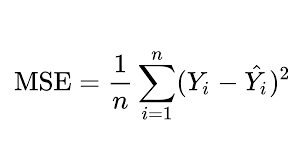
- 평균제곱오차는 예측값과 타깃 값의 차이를 제곱하여 더한 후에 샘플의 개수로 나눈 것
- 선형 회귀는 **매개변수가 없는 것이 장점이지만, 그래서 모델의 복잡도를 제어할 방법이 없음**

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X, y = mglearn.datasets.make_wave(n_samples=60)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
lr

LinearRegression()

> - **기울기 파라미터(w**, 가중치weight, 계수coefficient)는 **lr 객체의 coef_ 속성에 저장**
> - 편향(offset) 또는 절편(intercept) **파라미터(b)는 intercept_ 속성에 저장**
> - intercept_ 속성은 항상 실수 값 하나이지만, **coef_ 속성은 각 입력 특성에 하나씩 대응하는 NumPy 배열임**
> - scikit-learn은 훈련 데이터에서 유도된 속성은 항상 끝에 밑줄을 붙임, 사용자가 지정한 매개변수와 구분하기 위해서

In [3]:
print('기울기:', lr.coef_)
print('절편:', lr.intercept_)

기울기: [0.39390555]
절편: -0.03180434302675973


In [4]:
print('훈련 세트 점수:{:.2f}'.format(lr.score(X_train, y_train)))
print('테스트 세트 점수:{:.2f}'.format(lr.score(X_test, y_test)))

훈련 세트 점수:0.67
테스트 세트 점수:0.66


- 훈련 세트와 테스트 세트의 성능차이가 거의 없음, 1차원 데이터셋 사용으로 단순하므로 **위 결과는 과소적합 우려 있음**

> - **반대로 (특성이 많음) 고차원 데이터셋에서는 선형 모델의 성능이 매우 높아져 과적합 우려 있음**

In [13]:
# 예시, 보스턴 주택 가격 : 데이터포인트 506개, 특성은 104개
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

X, y = mglearn.datasets.load_extended_boston()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr2 = LinearRegression().fit(X_train, y_train)

In [14]:
print('훈련 세트 점수:{:.2f}'.format(lr2.score(X_train, y_train)))
print('테스트 세트 점수:{:.2f}'.format(lr2.score(X_test, y_test)))

훈련 세트 점수:0.95
테스트 세트 점수:0.61


- 위 결과는 훈련 데이터와 테스트 데이터 사이의 성능 차이가 크므로 **과적합 리스크 있음**
- **복잡도를 제어(과적합제어)할 수 있는 모델 사용이 필요 -> 리지 회귀**

#### <U>*리지(Ridge) 회귀*</U>
- 리지 회귀에서는 가중치(w) 선택은 훈련 데이터를 잘 예측하기 위해서 뿐만 아니라 **추가 제약 조건(규제)을 만족시키기 위한 목적 있음**
- **리지 규제: 가중치의 절대값을 가능한 한 작게 만드는 것** -> 모든 특성이 출력에 주는 영향을 최소화(기울기 최소)
- 리지 회귀에 사용하는 규제 방식을 L2 규제라고 함

- 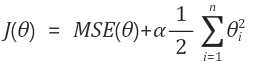

- 어떤 가중치(계수)도 0이 되지 않음 -> **모든 특성이 전부 반영되는 모델**
    > - **알파 값을 크게 하면 페널티의 효과가 커짐(가중치 감소), 알파 매개변수의 기본 값은 1임**
    > - 이 경우 모델의 복잡도가 낮아지면서 훈련 세트에서의 성능은 나빠지지만 더 일반화된 모델(테스트 점수 상승) 도출 가능
    > - **반대로 아주 작은 알파 값은 가중치를 거의 제한하지 않으므로 LinearRegression으로 만든 모델과 거의 같아짐** -> 과대적합 리스크

In [15]:
from sklearn.linear_model import Ridge
Ridge?

Init signature:
Ridge(
    alpha=1.0,
    *,
    fit_intercept=True,
    copy_X=True,
    max_iter=None,
    tol=0.0001,
    solver='auto',
    positive=False,
    random_state=None,
)
Docstring:     
Linear least squares with l2 regularization.

Minimizes the objective function::

||y - Xw||^2_2 + alpha * ||w||^2_2

This model solves a regression model where the loss function is
the linear least squares function and regularization is given by
the l2-norm. Also known as Ridge Regression or Tikhonov regularization.
This estimator has built-in support for multi-variate regression
(i.e., when y is a 2d-array of shape (n_samples, n_targets)).

Read more in the :ref:`User Guide <ridge_regression>`.

Parameters
----------
alpha : {float, ndarray of shape (n_targets,)}, default=1.0
    Constant that multiplies the L2 term, controlling regularization
    strength. `alpha` must be a non-negative float i.e. in `[0, inf)`.

    When `alpha = 0`, the objective is equivalent to ordinary least
    s

- **알고리즘**
    > - 기본 값은 'auto', **훈련 데이터가 희소 행렬이면 켤레기울기법(Conjugate Gradient Method)인 'sparse_cg' 사용, 그렇지 않으면 해석적으로 문제의 해를 구하는 방법인 'cholesky'를 사용**
    > - 계수 값을 양수로 강제하기 위해 **positive 매개변수를 True로 지정하면 L-BFGS-B 알고리즘인 'lbfgs' 사용됨**
    > - 이외에도 확률적 평균 경사 하강법('Stochastic Average Gradient Descent)인 'sag'와 SAG의 개선 버전인 'saga' 사용 가능, 이 두 가지 알고리즘은 특성과 샘플이 많은 경우에 종종 다른 알고리즘보다 속도가 빠름

In [16]:
ridge = Ridge().fit(X_train, y_train)
print('훈련 세트 점수:{:0.2f}'.format(ridge.score(X_train, y_train)))
print('테스트 세트 점수:{:0.2f}'.format(ridge.score(X_test, y_test)))

훈련 세트 점수:0.89
테스트 세트 점수:0.75


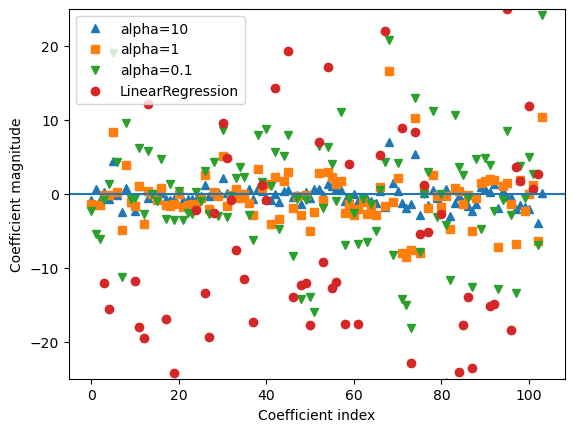

In [17]:
# 알파 값 매개변수 변화에 따른 가중치 변화 살펴보기
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)

plt.plot(ridge10.coef_, '^', label='alpha=10')
plt.plot(ridge.coef_, 's', label='alpha=1')
plt.plot(ridge01.coef_, 'v', label='alpha=0.1')

plt.plot(lr2.coef_, 'o', label='LinearRegression')

plt.xlabel("Coefficient index")
plt.ylabel('Coefficient magnitude')
xlims = plt.xlim()
plt.hlines(0, xlims[0], xlims[1])
plt.xlim(xlims)
plt.ylim(-25,25)
plt.legend()

- x 축은 coef_의 원소를 위치대로 나열한 것, 즉 x=0은 첫 번째 특성에 연관된 계수(기울기, 가중치)이고 x=1은 두 번째 특성에 연관된 계수(기울기, 가중치)임
- y축은 각 계수의 수치를 나타냄

> - 알파 값 고정(alpha=1)하고 훈련 데이터 크기 변화 검토
> - **데이터 셋의 크기에 따른 모델의 성능 변화를 나타낸 그래프를 학습 곡선(learning curve)이라고 함**
> - ~ 훈련하는 과정을 여러 번 반복하면서 학습하는 알고리즘에서는 **반복의 횟수에 따른 성능 변화를 나타내는 그래프를 학습 곡선**이라고 함

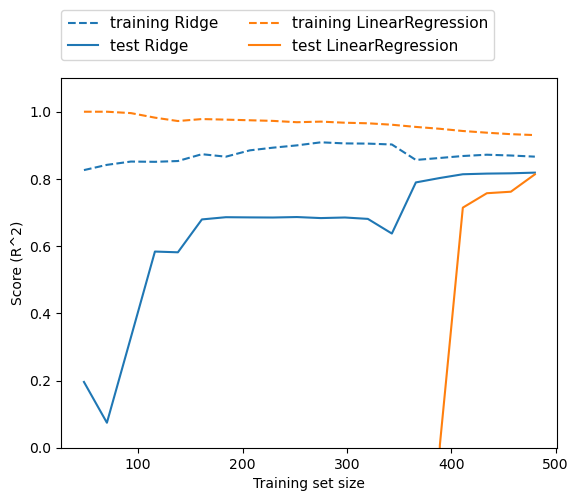

In [7]:
# 알파 값 고정(alpha=1)하고 훈련 데이터 크기 변화 검토 = 학습 곡선
mglearn.plots.plot_ridge_n_samples()

- 리지에는 규제가 적용되므로 **리지의 훈련 데이터 점수가 전체적으로 선형 회귀의 훈련 데이터 점수보다 낮음**
- 선형 회귀에서는 데이터수가 많아지면 훈련 데이터의 성능이 감소 -> 모델이 데이터를 기억하거나 과대적합하기 어려워짐
- 반대로 **테스트 데이터에서는 리지의 점수가 더 높으며, 특히 작은 데이터 셋에서 우수**
- 두 모델의 성능은 데이터가 많아질수록 좋아지고 **데이터가 충분히 주어지면 규제항이 더 이상 중요하지 않게 되어 리지와 선형 회귀의 성능이 같아짐**

#### <U>*라쏘(Lasso) 회귀*</U>
- 라쏘는 규제를 적용함에 있어서 **L1 norm(계수의 절대값의 합)을** 사용
- L1 규제의 결과로 어떤 계수는 0이됨 -> **완전히 제외되는 특성이 발생**, 일부 계수를 0으로 만들면 모델을 이해하기 쉬워지고 가장 중요한 특성이 무엇인지 판별 용이함
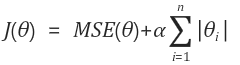
    > - **알파 값을 크게 하면 페널티의 효과가 커지고(가중치 감소), 알파 매개변수 기본 값은 1임**
    > - 알파 값을 너무 낮추면 규제의 효과가 없어져 과대적합이 되므로 LinearRegression의 결과와 비슷해짐
- Lasso는 L1, L2 규제를 함께 쓰는 엘라스틱넷(Elastic-Net) 방식에서 L2 규제가 빠진 것
    > - 한 특성씩 좌표축을 따라 최적화하는 **좌표하강법(coordinate descent) 방식**을 사용하며 **학습 과정이 반복적으로 진행되면서 최적의 값을 찾음**
    > - **알파 값을 줄이게 되면(규제 감소) 가장 낮은 오차를 찾아가는 이 반복 횟수가 늘어남**
    > - 수행한 반복 횟수는 Lasso 객체의 ***n_iter_*** 속성에 저장

In [11]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(X_train, y_train)
print('훈련 세트 점수:{:.2f}'.format(lasso.score(X_train, y_train)))
print('테스트 세트 점수:{:.2f}'.format(lasso.score(X_test, y_test)))
print('사용한 특성의 수:', np.sum(lasso.coef_ != 0))

훈련 세트 점수:0.29
테스트 세트 점수:0.21
사용한 특성의 수: 4


> - 위 과소적합 개선 목적으로 **알파 값을 줄이기 위해서 *max_iter*** (반복 실행하는 최대 횟수)의 **기본 값을 늘려야 함**

In [12]:
# 알파 감소 시, max_iter 기본 값을 증가시키지 않으면 경고 발생함
lasso001 = Lasso(alpha=0.01, max_iter=50000).fit(X_train, y_train)
print('훈련 세트 점수:{:.2f}'.format(lasso001.score(X_train, y_train)))
print('테스트 세트 점수:{:.2f}'.format(lasso001.score(X_test, y_test)))
print('사용한 특성의 수:', np.sum(lasso001.coef_ != 0))

훈련 세트 점수:0.90
테스트 세트 점수:0.77
사용한 특성의 수: 33


- **Ridge, Lasso, ElasticNet**
    > - 보통은 리지 회귀를 선호하나, 특성이 많고 그중 일부분만 중요하다면 라쏘(분석하기 쉬움)가 더 좋은 선택일 수 있음
    > - **일라스틱넷은 리지와 라쏘의 페널티를 결합**하여 좋은 성능을 낼 수 있지만 L1 규제와 L2 규제에 대한 **매개변수 2개**를 조정해야 함
        >> - L1 규제 = l1, L2 규제 = l2 매개변수로 생각하면 매개변수 **alpha** = l1 + l2, **l1_ratio** = l1 / (l1+l2)로 2개 조정 

#### <U>*QuantileRegressor*</U>
- 하나의 예측 값이 아니라 **예측의 백분위 간격을 구하는 데 사용할 수 있는 회귀 클래스**
- **quantile 매개변수**에 예측하려는 **백분위수**를 0 ~ 1 사이로 지정, 기본 값은 0.5 (중간값 예측)
- 라쏘 모델과 비슷하게 **알파 매개변수로 L1 규제를 조정**, 기본 값은 1

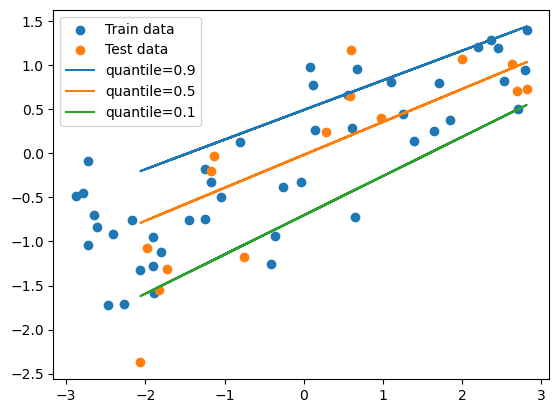

In [10]:
from sklearn.linear_model import QuantileRegressor

X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

pred_up = QuantileRegressor(quantile=0.9, alpha=0.01).fit(X_train, y_train).predict(X_test)
pred_med = QuantileRegressor(quantile=0.5, alpha=0.01).fit(X_train, y_train).predict(X_test)
pred_low = QuantileRegressor(quantile=0.1, alpha=0.01).fit(X_train, y_train).predict(X_test)

plt.scatter(X_train, y_train, label='Train data')
plt.scatter(X_test, y_test, label='Test data')

plt.plot(X_test, pred_up, label='quantile=0.9')
plt.plot(X_test, pred_med, label='quantile=0.5')
plt.plot(X_test, pred_low, label='quantile=0.1')

plt.legend()
plt.show()

#### <U>*분류용 선형 모델*</U>
- ***y = w[0] X x[0] + w[1] X x[1] + .... + w[p] X x[p] + b > 0*** // 이진분류 : 특성들의 가중치 합을 예측값으로 사용하는 것이 아니라 임계치 0과 비교, 0보다 작으면 클래스를 -1이라 하고 0보다 크면 1이라고 예측
- **분류용 선형 모델에서는 *결정 경계가* 입력의 선형 함수**
- 회귀와 비슷하게 분류에서의 선형 모델은 낮은 차원의 데이터에서는 결정 경계가 직선이거나 평면이어서 매우 제한적인 것처럼 보임, **하지만 고차원에서는 분류에 대한 선형 모델이 매우 강력해지며 특성이 많아지면 과대적합되지 않도록 주의 필요**

- 선형 모델을 학습 시키는 알고리즘은 다양한데, 다음의 두 가지 방법으로 구분
    > - 특정 계수와 절편의 조합이 훈련 데이터에 얼마나 잘 맞는지 측정하는 방법 : 기술적인 이유로, 알고리즘들이 만드는 잘못된 분류의 수를 최소화하도록 w와 b를 조정하는 것은 불가능, **손실 함수(loss function)에 대한 차이는 크게 중요하지 않음**
    > - 사용할 수 있는 규제가 있는지, 있다면 어떤 방식인지

- 가장 널리 알려진 두 개의 선형 분류 알고리즘은 **로지스틱 회귀(*linear_model.LogisticRegression*)와 서포트 벡터 머신(*svm.LinearSVC*)임**
- Ridge와 마찬가지로 이 두 모델은 기본적으로 L2 규제를 사용

In [15]:
from sklearn.linear_model import LogisticRegression 
LogisticRegression?

Init signature:
LogisticRegression(
    penalty='l2',
    *,
    dual=False,
    tol=0.0001,
    C=1.0,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    multi_class='auto',
    verbose=0,
    warm_start=False,
    n_jobs=None,
    l1_ratio=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

In the multiclass case, the training algorithm uses the one-vs-rest (OvR)
scheme if the 'multi_class' option is set to 'ovr', and uses the
cross-entropy loss if the 'multi_class' option is set to 'multinomial'.
(Currently the 'multinomial' option is supported only by the 'lbfgs',
'sag', 'saga' and 'newton-cg' solvers.)

This class implements regularized logistic regression using the
'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
that regularization is applied by default**. It can handle both dense
and sparse input. Use C-ordered arrays or CSR matrices containi

- **알고리즘**
    > - 규제항 적용 시 **penalty 매개변수에 L1과 L2 규제를 의미하는 'l1', 'l2' 그리고 L1, L2 규제를 모두 사용하는 'elasticnet' 마지막으로 규제를 사용하지 않으려면 'none'으로 지정 가능**
    > - 사용할 알고리즘을 지정하는 **solver 매개변수를 'saga'로 지정하면 모든 패널티를 지정**, **'liblinear'로 지정하면 'l1', 'l2'를 지정 가능**, 그외 'newton-cg', 'lbfgs', 'sag'는 'l2'와 'none'만 지원

- LinearSVC
> - LinearSVC는 loss 매개변수에 사용할 손실함수를 지정, 기본값은 제곱힌지손실인 'squared_hinge', 제곱힌지손실함수는 penalty 매개변수에 'l1'과 'l2'를 지정 가능
> - 다른 손실함수로는 힌지손실인 'hinge'를 지정, 이 경우 penalty 매개변수에 'l2'만 사용 가능

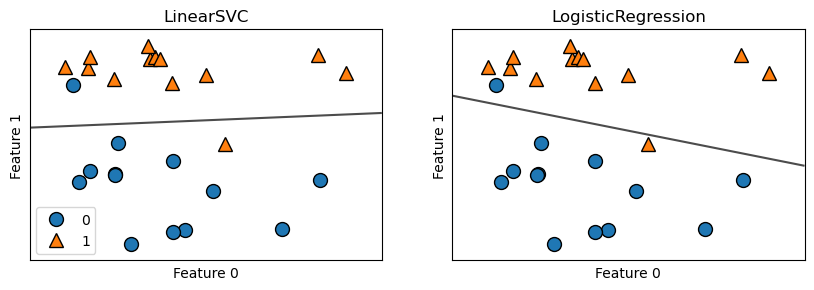

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

X, y = mglearn.datasets.make_forge()

fig, axes = plt.subplots(1, 2, figsize=(10,3))

for model, ax in zip([LinearSVC(max_iter=5000), LogisticRegression()], axes):
    clf = model.fit(X, y)
    mglearn.plots.plot_2d_separator(clf, X, fill=False, eps=0.5,
                                    ax=ax, alpha=0.7)
    mglearn.discrete_scatter(X[:,0], X[:,1], y, ax=ax)
    ax.set_title(clf.__class__.__name__)
    ax.set_xlabel('Feature 0')
    ax.set_ylabel('Feature 1')
axes[0].legend()

> - 규제의 강도를 결정하는 매개변수는 C, 기본 값 = 1
> - **C를 높이면 규제가 감소** -> 훈련 세트에 가능한 최대한 맞추려고 함, 개개의 데이터 포인트를 정확히 분류하려고 노력 -> 과대적합 리스크
> - **C를 낮추면 규제가 증가** -> 계수 벡터(w)가 0에 가까워지도록 만듦, 데이터 포인트 중 다수에 맞추려고 함 -> 과소적합 리스크

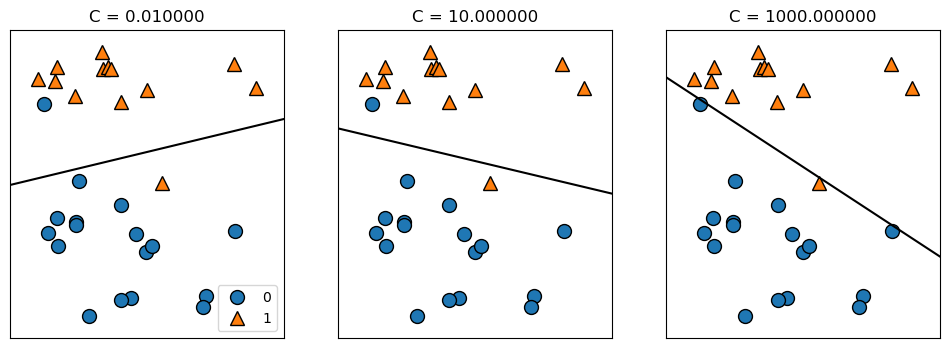

In [9]:
mglearn.plots.plot_linear_svc_regularization()

- (오)C 증가 -> 규제 감소, 클래스 0의 모든 데이터 포인트를 올바로 분류 하였으나 과대적합 리스크 큼
- (왼)C 감소 -> 규제 증가, 비교적 수평에 가까운 결정 경계

In [18]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                    stratify=cancer.target, random_state=42)

# C 기본값 1 사용
logreg = LogisticRegression(max_iter=5000).fit(X_train, y_train)

print('훈련 세트 점수:{:.3f}'.format(logreg.score(X_train, y_train)))
print('테스트 세트 점수:{:.3f}'.format(logreg.score(X_test, y_test)))

훈련 세트 점수:0.958
테스트 세트 점수:0.958


In [19]:
# 규제 감소, C = 100으로 증가
logreg100 = LogisticRegression(C=100, max_iter=5000).fit(X_train, y_train)

print('훈련 세트 점수:{:.3f}'.format(logreg100.score(X_train, y_train)))
print('테스트 세트 점수:{:.3f}'.format(logreg100.score(X_test, y_test)))

훈련 세트 점수:0.984
테스트 세트 점수:0.965


In [20]:
# 규제 증가, C = 0.01로 감소
logreg001 = LogisticRegression(C=0.01, max_iter=5000).fit(X_train, y_train)
print('훈련 세트 점수:{:.3f}'.format(logreg001.score(X_train, y_train)))
print('테스트 세트 점수:{:.3f}'.format(logreg001.score(X_test, y_test)))

훈련 세트 점수:0.953
테스트 세트 점수:0.951


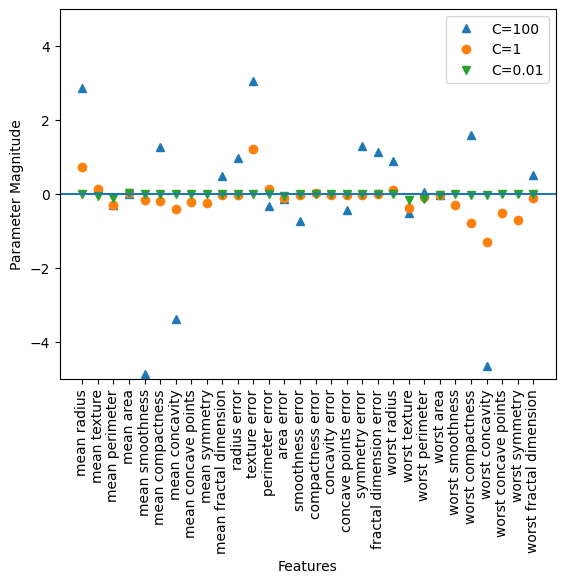

In [21]:
# C에 따른 모델 계수 확인
plt.plot(logreg100.coef_.T, '^', label='C=100')
plt.plot(logreg.coef_.T, 'o', label='C=1')
plt.plot(logreg001.coef_.T, 'v', label='C=0.01')
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
xlims = plt.xlim()
plt.hlines(0, xlims[0], xlims[1])
plt.xlim(xlims)
plt.ylim(-5,5)
plt.xlabel('Features')
plt.ylabel('Parameter Magnitude')
plt.legend()

- 로지스틱회귀 분류는 기본적으로 L2 규제를 사용하므로 Ridge로 만든 모습과 유사
- **규제를 강하게 할수록 계수들은 0에 근접, 완전히 0이 되지는 않음**
- 각 특성들의 **계수 부호 및 크기**는 양성, 음성 결과 판단과 연결되므로 **선형 모델의 계수는 항상 주의 깊게 살펴보아야 함** 

> - **몇 개의 특성만 사용**하여 더 이해하기 쉬운 모델을 만들고자 한다면 **L1 규제를 사용**

C=0.001인 l1 로지스틱 회귀의 훈련 정확도: 0.91
C=0.001인 l1 로지스틱 회귀의 테스트 정확도: 0.92
C=1.000인 l1 로지스틱 회귀의 훈련 정확도: 0.96
C=1.000인 l1 로지스틱 회귀의 테스트 정확도: 0.96
C=100.000인 l1 로지스틱 회귀의 훈련 정확도: 0.99
C=100.000인 l1 로지스틱 회귀의 테스트 정확도: 0.98


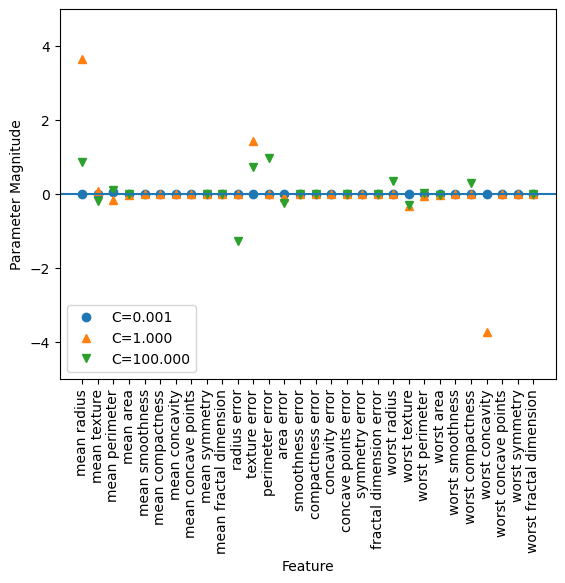

In [22]:
for C, marker in zip([0.001, 1, 100], ['o','^','v']):
    lr_l1 = LogisticRegression(solver='liblinear', C=C, penalty='l1', max_iter=1000).fit(X_train, y_train)
    print('C={:.3f}인 l1 로지스틱 회귀의 훈련 정확도: {:.2f}'.format(C, lr_l1.score(X_train, y_train)))
    print('C={:.3f}인 l1 로지스틱 회귀의 테스트 정확도: {:.2f}'.format(C, lr_l1.score(X_test, y_test)))
    plt.plot(lr_l1.coef_.T, marker, label='C={:.3f}'.format(C))

plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
xlims = plt.xlim()
plt.hlines(0, xlims[0], xlims[1])
plt.xlim(xlims)
plt.xlabel('Feature')
plt.ylabel('Parameter Magnitude')

plt.ylim(-5,5)
plt.legend(loc=3)

#### <U>*다중 클래스 분류용 선형 모델*</U>
- 이진 분류 알고리즘을 다중 클래스 분류 알고리즘으로 **확장하는 보편적인 기법은 일대다 방법**
> - 일대다 방식은 각 클래스를 다른 모든 클래스와 구분하도록 이진 분류 모델을 학습
> - **즉, 클래스의 수만큼 이진 분류 모델이 생성, 각 클래스가 계수 벡터(w)와 절편(b)을 하나씩 갖게됨**
> - 이렇게 만들어진 모든 이진 분류기가 작동하여 가장 높은 점수를 내는 분류기의 클래스를 예측값으로 선택

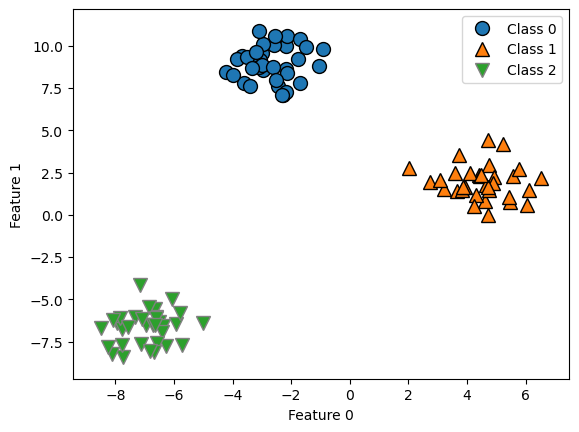

In [23]:
from sklearn.datasets import make_blobs

X, y = make_blobs(random_state=42)
mglearn.discrete_scatter(X[:,0], X[:,1], y)

plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.legend(['Class 0', 'Class 1', 'Class 2'])

In [24]:
from sklearn.svm import LinearSVC
linear_svm = LinearSVC().fit(X, y)
print(linear_svm.coef_.shape) # 3개 클래스에 각각 w벡터 (특성 2개)
print(linear_svm.intercept_.shape) # 3개 클래스에 해당하는 각 절편

(3, 2)
(3,)


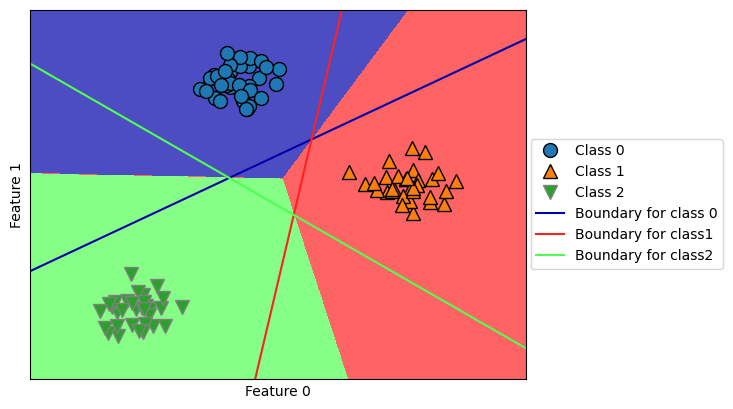

In [25]:
# 경계 시각화
mglearn.discrete_scatter(X[:,0], X[:,1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_,
                                  mglearn.cm3.colors):
    plt.plot(line, -(line*coef[0] + intercept)/coef[1], c=color)
    plt.ylim(-10, 15)
    plt.xlim(-10, 8)
    plt.xlabel('Feature 0')
    plt.ylabel('Feature 1')
    plt.legend(['Class 0', 'Class 1', 'Class 2', 
                'Boundary for class 0', 'Boundary for class1', 'Boundary for class2'], loc=[1.01, 0.3])
    
# 2차원 평면의 모든 포인트에 대한 예측 결과
mglearn.plots.plot_2d_classification(linear_svm, X, fill=True, alpha=0.7)

#### <U>*SGDClassifier & SGDRegressor*</U>
- 확률적 경사 하강법(Stochastic Gradient Descent)을 사용하여 다양한 선형 모델을 훈련
> - **SGDClassifier의 'loss' 매개변수 기본 값은 힌지 손실 'hinge' -> 서포트 벡터 머신 모델 훈련, 'log_loss'로 지정 -> 로지스틱 회귀**
> - **SGDRegressor 'loss' 매개변수 기본 값은 'squared_error' -> 릿지 모델 훈련**
- 두 클래스 *penalty* 매개변수에 'l1', 'l2', 'elasticnet' 지정 가능(기본 값 l2)
> - 규제 강도는 모두 alpha 매개변수로 조정, 기본 값은 0.0001이며 클수록 규제 강화
- 알고리즘 반복 횟수는 max_iter 매개변수로 지정하며 기본 값은 1,000, **조기종료를 위한 *early_stopping* 매개변수** 존재
> - 기본 값은 False로 이것을 True로 지정하면 훈련 데이터에서 *validation_fraction* (기본 0.1)에 지정한 비율만큼 검증 데이터로 사용하여 ***n_iter_no_change* (기본 5) 반복 동안 훈련 세트 검증 점수가 적어도 *tol* (기본 1e-3) 값 만큼 향상되지 않으면 훈련을 종료** 
- **학습률 매개변수 : *learning_rate***
> - **기본 값은 'optimal'로 반복 횟수에 따라 비례적으로 감소**
> - 'constant'는 eta0 (기본 0) 매개변수에 지정한 값을 사용, 'invscaling'은 eta0에서 시작하여 지수적으로 감소
> - **'adaptive'는 eta0에서 지정한 값에서 시작하여 조기 종료 조건이 될 때마다 5배씩 줄이며 학습률이 1e-6보다 작아지면 알고리즘 종료**
- 대용량 데이터에 사용할 수 있고 속도가 빠르다는 장점이 있으나, **튜닝할 하이퍼파라미터가 많고 특성 스케일링에 민감함**

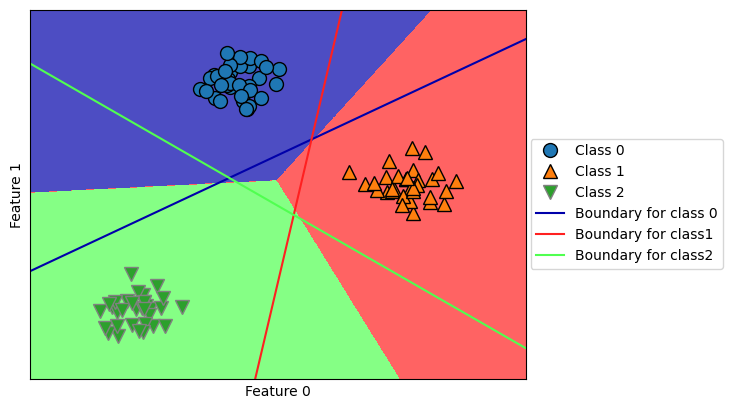

In [26]:
from sklearn.linear_model import SGDClassifier

sgd_c = SGDClassifier(alpha=0.01, learning_rate='adaptive', eta0=0.1, random_state=42, n_jobs=-1)
sgd_c.fit(X, y)

mglearn.plots.plot_2d_classification(sgd_c, X, fill=True, alpha=0.7)

mglearn.discrete_scatter(X[:,0], X[:,1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_,
                                  mglearn.cm3.colors):
    plt.plot(line, -(line*coef[0] + intercept)/coef[1], c=color)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.legend(['Class 0', 'Class 1', 'Class 2', 
                'Boundary for class 0', 'Boundary for class1', 'Boundary for class2'], loc=[1.01, 0.3])
plt.show()

In [27]:
from sklearn.linear_model import SGDRegressor

X, y = mglearn.datasets.load_extended_boston()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

sgd_r = SGDRegressor(learning_rate='adaptive', eta0=0.1, random_state=42)
sgd_r.fit(X_train, y_train)

print('훈련 세트 점수:{:.2f}'.format(sgd_r.score(X_train, y_train)))
print('테스트 세트 점수:{:.2f}'.format(sgd_r.score(X_test, y_test)))

훈련 세트 점수:0.91
테스트 세트 점수:0.77


In [28]:
data_url = "data/boston.csv"
raw_df = pd.read_csv(data_url)
data = raw_df.drop(['MEDV', 'CAT. MEDV'], axis=1).values
target = raw_df['MEDV'].values

data

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]])